<a href="https://colab.research.google.com/github/Tirthesh123/ATM-Interface/blob/main/Presonality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Descriptive Statistics**

In [ ]:
# Importing necessary libraries
import pandas as pd

# Load the dataset
file_path = '/content/drive/My Drive/ml/personality.csv'
df = pd.read_csv(file_path)

# Get the number of rows and columns in the DataFrame
num_rows, num_columns = df.shape

# Display the results
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")

# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(df.head())

# Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe(include='all'))



Number of rows: 128061
Number of columns: 9
First few rows of the dataset:
    Age  Gender  Education  Introversion Score  Sensing Score  Thinking Score  \
0  19.0    Male          0             9.47080       7.141434         6.03696   
1  27.0  Female          0             5.85392       6.160195         0.80552   
2  21.0  Female          0             7.08615       3.388433         2.66188   
3  28.0    Male          0             2.01892       4.823624         7.30625   
4  36.0  Female          1             9.91703       4.755080         5.31469   

   Judging Score    Interest Personality  
0       4.360278     Unknown        ENFP  
1       4.221421      Sports        ESFP  
2       5.127320     Unknown        ENFP  
3       5.986550      Others        INTP  
4       4.677213  Technology        ENFP  

Descriptive Statistics:
                  Age  Gender      Education  Introversion Score  \
count   128061.000000  128061  128061.000000       128061.000000   
unique            N

# **Preprocessing**

In [ ]:
# Check for null values in the DataFrame
null_values = df.isnull().sum()

# Display the null values
print("Null values in each column:")
print(null_values)


Null values in each column:
Age                   0
Gender                0
Education             0
Introversion Score    0
Sensing Score         0
Thinking Score        0
Judging Score         0
Interest              0
Personality           0
dtype: int64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features and target
X = df.drop('Personality', axis=1)
y = df['Personality']

# Encoding the target (Personality)
le_personality = LabelEncoder()
y_encoded = le_personality.fit_transform(y)  # Convert 'Personality' to numerical values

# Identify numerical and categorical columns
numerical_features = ['Age', 'Introversion Score', 'Sensing Score', 'Thinking Score', 'Judging Score']
categorical_features = ['Gender', 'Education', 'Interest']  # Personality is handled separately

# Create a Column Transformer for other features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),  # Scale numerical features
        ('cat', OneHotEncoder(), categorical_features)  # One-hot encode categorical features
    ])

# Preprocess the features
X_processed = preprocessor.fit_transform(X)

# Split the preprocessed data into training and test sets
X_train_processed, X_test_processed, y_train_processed, y_test_processed = train_test_split(
    X_processed, y_encoded, test_size=0.2, random_state=42)

# Check the shape of the processed features and the target
print("Processed feature shapes:")
print(f"Training features: {X_train_processed.shape}")
print(f"Test features: {X_test_processed.shape}")
print(f"Target variable (y) shape: {y_train_processed.shape}")



Processed feature shapes:
Training features: (102448, 14)
Test features: (25613, 14)
Target variable (y) shape: (102448,)


# Detecting outliers using box plot

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.

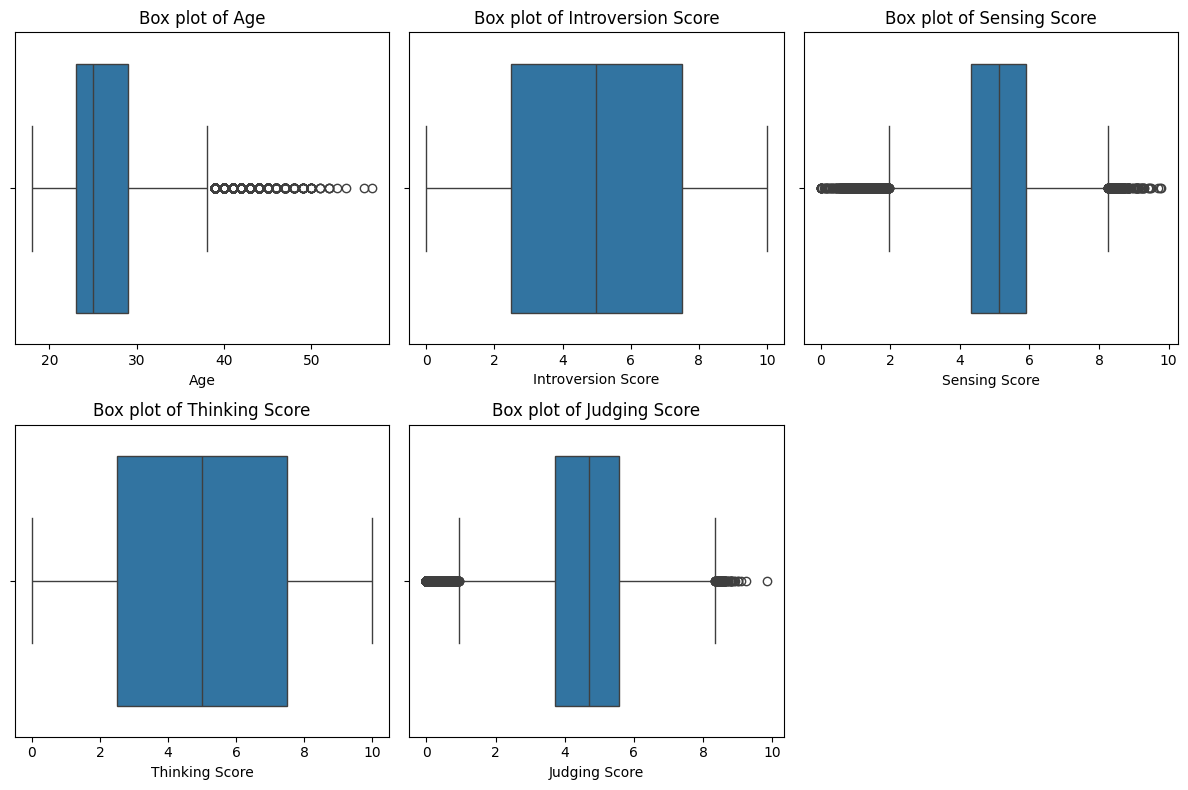

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Calculate Z-scores for the relevant numerical features
numerical_features = ['Age', 'Introversion Score', 'Sensing Score', 'Thinking Score', 'Judging Score']
z_scores = np.abs(zscore(df[numerical_features]))

# Set a threshold for determining outliers
threshold = 3

# Identify outlier rows based on Z-scores
outlier_indices = np.where(z_scores > threshold)

# Create a list of outlier rows
outlier_rows = []
for row in outlier_indices[0]:
    outlier_rows.append(df.iloc[row])

# Convert to DataFrame for better visualization
outliers_df = pd.DataFrame(outlier_rows).drop_duplicates()

# Optional: Visualize the outliers using box plots
plt.figure(figsize=(12, 8))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df[feature])
    plt.title(f'Box plot of {feature}')
plt.tight_layout()
plt.show()


# Handaling outliers using capping

in the features age, sensing and judging score

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

# Assuming df is your DataFrame
# Define thresholds for capping (3 standard deviations)
thresholds = {
    'Age': 3,
    'Sensing Score': 3,
    'Judging Score': 3
}

# Capping outliers based on Z-scores
for feature in thresholds.keys():
    # Calculate mean and standard deviation
    mean = df[feature].mean()
    std_dev = df[feature].std()

    # Calculate upper and lower limits
    upper_limit = mean + thresholds[feature] * std_dev
    lower_limit = mean - thresholds[feature] * std_dev

    # Cap outliers
    df[feature] = np.where(df[feature] > upper_limit, upper_limit,
                           np.where(df[feature] < lower_limit, lower_limit, df[feature]))

# Check the DataFrame after capping outliers
print("DataFrame after handling outliers:")
print(df.describe())


DataFrame after handling outliers:
                 Age      Education  Introversion Score  Sensing Score  \
count  128061.000000  128061.000000       128061.000000  128061.000000   
mean       26.327445       0.411156            4.996387       5.083061   
std         4.832646       0.492045            2.888636       1.178185   
min        18.000000       0.000000            0.000040       1.532184   
25%        23.000000       0.000000            2.490710       4.315659   
50%        25.000000       0.000000            4.993640       5.124169   
75%        29.000000       1.000000            7.500170       5.892288   
max        41.073159       1.000000            9.999990       8.631602   

       Thinking Score  Judging Score  
count   128061.000000  128061.000000  
mean         4.988040       4.579782  
std          2.886018       1.386758  
min          0.000050       0.403548  
25%          2.488630       3.709353  
50%          4.984180       4.690653  
75%          7.492550    

# Calculate the features importance using random forest

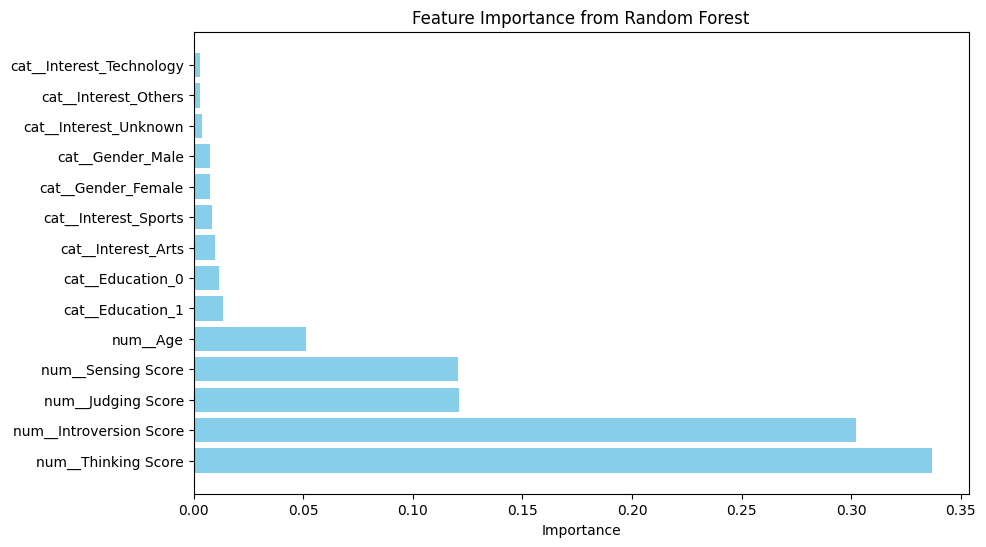

Feature Importances:
                     Feature  Importance
3        num__Thinking Score    0.336728
1    num__Introversion Score    0.302397
4         num__Judging Score    0.121018
2         num__Sensing Score    0.120803
0                   num__Age    0.051108
8           cat__Education_1    0.013501
7           cat__Education_0    0.011728
9         cat__Interest_Arts    0.009901
11      cat__Interest_Sports    0.008572
5         cat__Gender_Female    0.007468
6           cat__Gender_Male    0.007274
13     cat__Interest_Unknown    0.003829
10      cat__Interest_Others    0.002963
12  cat__Interest_Technology    0.002710


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Fit the model on the processed training data
rf_model.fit(X_train_processed, y_train_processed)

# Get feature importances
importances = rf_model.feature_importances_

# Create a DataFrame for feature importance
# Ensure you have imported 'preprocessor' correctly
feature_names = preprocessor.get_feature_names_out()  # This works with newer versions of scikit-learn
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importance from Random Forest")
plt.show()

# Displaying the importance DataFrame
print("Feature Importances:")
print(feature_importance_df)

# **Done features selction**

In [ ]:
import pandas as pd

# Define the selected features based on importance
selected_features = [
    'num__Thinking Score',
    'num__Introversion Score',
    'num__Judging Score',
    'num__Sensing Score',
    'num__Age'
]

# Convert the processed training and test features back to DataFrame for selection
X_train_processed_df = pd.DataFrame(X_train_processed, columns=preprocessor.get_feature_names_out())
X_test_processed_df = pd.DataFrame(X_test_processed, columns=preprocessor.get_feature_names_out())

# Create a new DataFrame with selected features
X_train_selected = X_train_processed_df[selected_features]
X_test_selected = X_test_processed_df[selected_features]

# Create a DataFrame for the target labels in the training set
y_train_df = pd.DataFrame(y_train_processed, columns=['Personality'])

# Create a combined DataFrame with selected features and target for training set
train_df_rf = pd.concat([X_train_selected.reset_index(drop=True), y_train_df.reset_index(drop=True)], axis=1)

# Check the columns of the new DataFrame
print("Columns in the new training DataFrame:")
print(train_df_rf.columns)

# Confirm the number of columns
print(f"Number of columns: {len(train_df_rf.columns)}")

# Display a sample of the new DataFrame
print(train_df_rf.head())


Columns in the new training DataFrame:
Index(['num__Thinking Score', 'num__Introversion Score', 'num__Judging Score',
       'num__Sensing Score', 'num__Age', 'Personality'],
      dtype='object')
Number of columns: 6
   num__Thinking Score  num__Introversion Score  num__Judging Score  \
0             1.118258                 0.204898            0.845804   
1             1.371285                -1.037769            1.251450   
2            -0.941872                 0.939112           -1.602912   
3             0.997814                -0.704826            0.611550   
4             0.969578                 1.605423           -0.537602   

   num__Sensing Score  num__Age  Personality  
0           -1.947355  0.743868            3  
1           -0.375205 -1.497369           10  
2           -0.885727 -0.886122            1  
3            0.694873 -0.274876           11  
4            0.300641  1.151366            3  


# **Calculate weather the classes are imblanace or not?**

Class counts:
Personality
1     27441
9     19816
3     19729
11    13717
5      3851
0      3084
13     2786
7      2701
8      2308
2      2252
15     1928
10     1558
4       453
6       314
12      296
14      214
Name: count, dtype: int64


<ipython-input-9-8b1a6b82bdd1>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping w

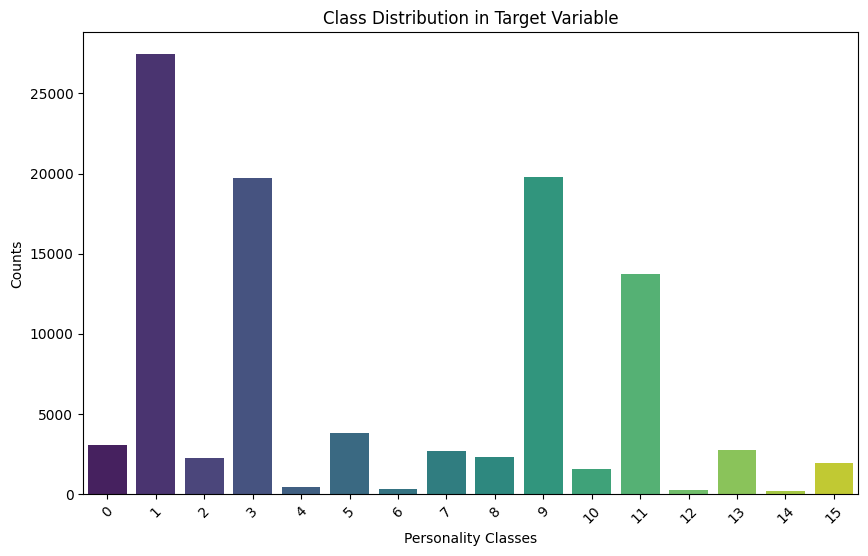

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each class in the target variable
class_counts = y_train_df['Personality'].value_counts()

# Display the counts of each class
print("Class counts:")
print(class_counts)

# Plotting the class distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Class Distribution in Target Variable')
plt.xlabel('Personality Classes')
plt.ylabel('Counts')
plt.xticks(rotation=45)
plt.show()


# **Calculated class weight using**
weight(c)= N/ count(c)

Where:
N is the total number of samples in the dataset.

count(c) is the number of samples belonging to class c.

In [ ]:
# Import necessary libraries
import pandas as pd

def calculate_class_weights(df, target_column):
    # Count total number of samples
    N = len(df)

    # Count the number of samples for each class
    class_counts = df[target_column].value_counts()

    # Calculate weights
    class_weights = {label: N / count for label, count in class_counts.items()}

    # Display the calculated class weights
    print("Class Weights:")
    for label, weight in class_weights.items():
        print(f"Class '{label}': {weight:.4f}")

    return class_weights

# Example usage
# Assuming train_df_rf is already defined and contains the 'Personality' column
class_weights = calculate_class_weights(train_df_rf, 'Personality')


Class Weights:
Class '1': 3.7334
Class '9': 5.1700
Class '3': 5.1928
Class '11': 7.4687
Class '5': 26.6030
Class '0': 33.2192
Class '13': 36.7724
Class '7': 37.9297
Class '8': 44.3882
Class '2': 45.4920
Class '15': 53.1369
Class '10': 65.7561
Class '4': 226.1545
Class '6': 326.2675
Class '12': 346.1081
Class '14': 478.7290


# I used XGbosst because

*   target variable have multiple class lables
*   XGbosst can handel class imbalnce by assing weight



Calculated Class Weights:
Class '1': 3.7334
Class '9': 5.1700
Class '3': 5.1928
Class '11': 7.4687
Class '5': 26.6030
Class '0': 33.2192
Class '13': 36.7724
Class '7': 37.9297
Class '8': 44.3882
Class '2': 45.4920
Class '15': 53.1369
Class '10': 65.7561
Class '4': 226.1545
Class '6': 326.2675
Class '12': 346.1081
Class '14': 478.7290
Classification Report (No Weights):
              precision    recall  f1-score   support

           0       0.66      0.75      0.70      3084
           1       0.90      0.87      0.89     27441
           2       0.68      0.78      0.73      2252
           3       0.87      0.88      0.87     19729
           4       0.92      0.94      0.93       453
           5       0.90      0.89      0.89      3851
           6       0.92      0.94      0.93       314
           7       0.89      0.90      0.90      2701
           8       0.69      0.76      0.73      2308
           9       0.87      0.86      0.86     19816
          10       0.72      0.78

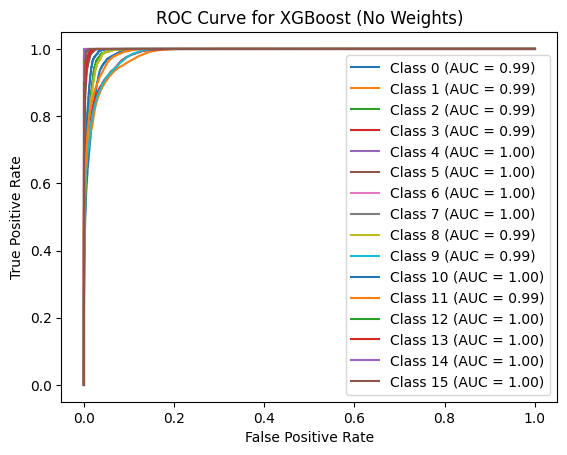

Classification Report (With Weights):
              precision    recall  f1-score   support

           0       0.58      0.88      0.70      3084
           1       0.94      0.76      0.84     27441
           2       0.61      0.94      0.74      2252
           3       0.87      0.80      0.84     19729
           4       0.80      1.00      0.89       453
           5       0.80      0.93      0.86      3851
           6       0.81      1.00      0.90       314
           7       0.78      0.96      0.86      2701
           8       0.60      0.95      0.73      2308
           9       0.86      0.81      0.83     19816
          10       0.60      0.98      0.74      1558
          11       0.83      0.84      0.84     13717
          12       0.81      1.00      0.90       296
          13       0.79      0.96      0.87      2786
          14       0.89      1.00      0.94       214
          15       0.80      0.98      0.88      1928

    accuracy                           0.8

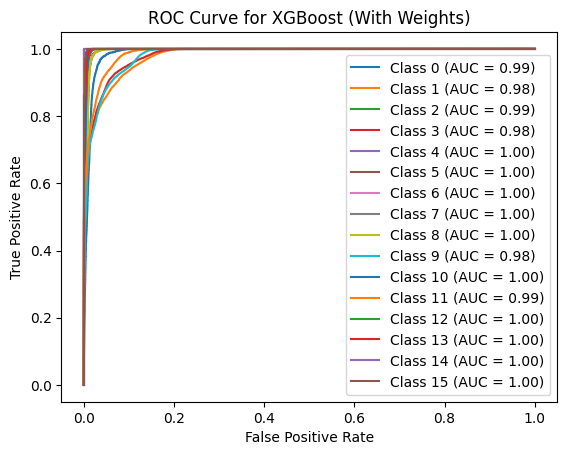

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Define the target variable from the training DataFrame
y_train = train_df_rf['Personality']

# Count total number of samples
N = len(y_train)

# Count the number of samples for each class
class_counts = y_train.value_counts()

# Calculate class weights based on the inverse of the class frequencies
class_weights = {label: N / count for label, count in class_counts.items()}

# Print the calculated class weights
print("Calculated Class Weights:")
for label, weight in class_weights.items():
    print(f"Class '{label}': {weight:.4f}")

# Create a sample weight array
sample_weights = y_train.map(class_weights).values  # Map the weights according to the labels

# Binarize the labels for multi-class ROC
y_train_binarized = label_binarize(y_train, classes=sorted(class_weights.keys()))
n_classes = y_train_binarized.shape[1]

# ===================== XGBoost without weights =========================
xgb_model_no_weight = xgb.XGBClassifier(random_state=42)

# Fit the model without class weights using the selected features
xgb_model_no_weight.fit(X_train_selected, y_train)

# Predictions on the training set
y_train_pred_no_weight = xgb_model_no_weight.predict(X_train_selected)

# Print classification report for the model without class weights
print("Classification Report (No Weights):")
print(classification_report(y_train, y_train_pred_no_weight))

# ROC for XGBoost without weights
y_train_prob_no_weight = xgb_model_no_weight.predict_proba(X_train_selected)

fpr_no_weight = {}
tpr_no_weight = {}
roc_auc_no_weight = {}

for i in range(n_classes):
    fpr_no_weight[i], tpr_no_weight[i], _ = roc_curve(y_train_binarized[:, i], y_train_prob_no_weight[:, i])
    roc_auc_no_weight[i] = auc(fpr_no_weight[i], tpr_no_weight[i])

# Plot ROC curve for XGBoost without weights
plt.figure()
for i in range(n_classes):
    plt.plot(fpr_no_weight[i], tpr_no_weight[i], label=f'Class {i} (AUC = {roc_auc_no_weight[i]:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost (No Weights)')
plt.legend(loc="lower right")
plt.show()

# ===================== XGBoost with weights ============================
xgb_model_with_weight = xgb.XGBClassifier(random_state=42)

# Fit the model with sample weights using the selected features
xgb_model_with_weight.fit(X_train_selected, y_train, sample_weight=sample_weights)

# Predictions on the training set with sample weights
y_train_pred_with_weight = xgb_model_with_weight.predict(X_train_selected)

# Print classification report for the model with weights
print("Classification Report (With Weights):")
print(classification_report(y_train, y_train_pred_with_weight))

# ROC for XGBoost with weights
y_train_prob_with_weight = xgb_model_with_weight.predict_proba(X_train_selected)

fpr_with_weight = {}
tpr_with_weight = {}
roc_auc_with_weight = {}

for i in range(n_classes):
    fpr_with_weight[i], tpr_with_weight[i], _ = roc_curve(y_train_binarized[:, i], y_train_prob_with_weight[:, i])
    roc_auc_with_weight[i] = auc(fpr_with_weight[i], tpr_with_weight[i])

# Plot ROC curve for XGBoost with weights
plt.figure()
for i in range(n_classes):
    plt.plot(fpr_with_weight[i], tpr_with_weight[i], label=f'Class {i} (AUC = {roc_auc_with_weight[i]:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost (With Weights)')
plt.legend(loc="lower right")
plt.show()


Calculated Class Weights:
Class '1': 3.7334
Class '9': 5.1700
Class '3': 5.1928
Class '11': 7.4687
Class '5': 26.6030
Class '0': 33.2192
Class '13': 36.7724
Class '7': 37.9297
Class '8': 44.3882
Class '2': 45.4920
Class '15': 53.1369
Class '10': 65.7561
Class '4': 226.1545
Class '6': 326.2675
Class '12': 346.1081
Class '14': 478.7290
Classification Report (With Weights and Regularization):
              precision    recall  f1-score   support

           0       0.58      0.89      0.70      3084
           1       0.94      0.76      0.84     27441
           2       0.59      0.92      0.72      2252
           3       0.87      0.80      0.83     19729
           4       0.75      1.00      0.85       453
           5       0.79      0.91      0.85      3851
           6       0.77      1.00      0.87       314
           7       0.77      0.95      0.85      2701
           8       0.57      0.93      0.71      2308
           9       0.86      0.79      0.83     19816
          10

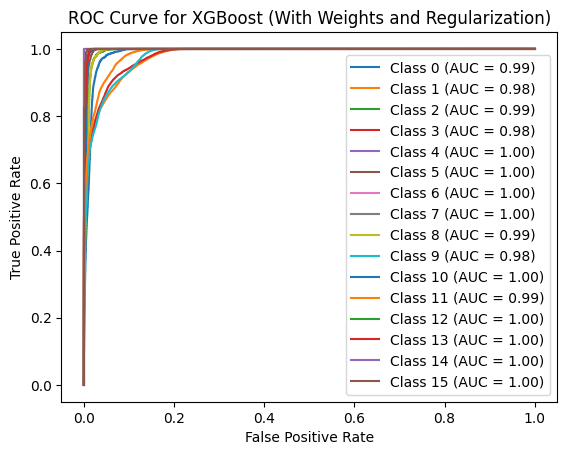

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Define the target variable from the training DataFrame
y_train = train_df_rf['Personality']

# Count total number of samples
N = len(y_train)

# Count the number of samples for each class
class_counts = y_train.value_counts()

# Calculate class weights based on the inverse of the class frequencies
class_weights = {label: N / count for label, count in class_counts.items()}

# Print the calculated class weights
print("Calculated Class Weights:")
for label, weight in class_weights.items():
    print(f"Class '{label}': {weight:.4f}")

# Create a sample weight array
sample_weights = y_train.map(class_weights).values  # Map the weights according to the labels

# Binarize the labels for multi-class ROC
y_train_binarized = label_binarize(y_train, classes=sorted(class_weights.keys()))
n_classes = y_train_binarized.shape[1]

# ===================== XGBoost with weights and regularization =========
xgb_model_with_regularization = xgb.XGBClassifier(
    random_state=42,
    alpha=1.0,        # Adjusted L1 regularization term on weights (Lasso)
    reg_lambda=20.0    # L2 regularization term on weights (Ridge)
)

# Fit the model with sample weights using the selected features
xgb_model_with_regularization.fit(X_train_selected, y_train, sample_weight=sample_weights)

# Predictions on the training set with sample weights
y_train_pred_with_regularization = xgb_model_with_regularization.predict(X_train_selected)

# Print classification report for the model with weights and regularization
print("Classification Report (With Weights and Regularization):")
print(classification_report(y_train, y_train_pred_with_regularization))

# ROC for XGBoost with weights and regularization
y_train_prob_with_regularization = xgb_model_with_regularization.predict_proba(X_train_selected)

fpr_with_regularization = {}
tpr_with_regularization = {}
roc_auc_with_regularization = {}

for i in range(n_classes):
    fpr_with_regularization[i], tpr_with_regularization[i], _ = roc_curve(y_train_binarized[:, i], y_train_prob_with_regularization[:, i])
    roc_auc_with_regularization[i] = auc(fpr_with_regularization[i], tpr_with_regularization[i])

# Plot ROC curve for XGBoost with weights and regularization
plt.figure()
for i in range(n_classes):
    plt.plot(fpr_with_regularization[i], tpr_with_regularization[i], label=f'Class {i} (AUC = {roc_auc_with_regularization[i]:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost (With Weights and Regularization)')
plt.legend(loc="lower right")
plt.show()


# **I tried different boosting techniques**

**#** XGBoost and LightGBM are optimized for speed and efficiency with large
datasets,

**#** while CatBoost excels in handling categorical features.

**#** AdaBoost is effective in emphasizing misclassified samples and is generally simpler.

**#** Gradient Boosting is the foundational approach, providing flexibility but may require more tuning for performance and handling imbalanced classes.

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004710 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1057
[LightGBM] [Info] Number of data points in the train set: 102448, number of used features: 5
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from score -2.772589
[LightGBM] [Info] Start training from

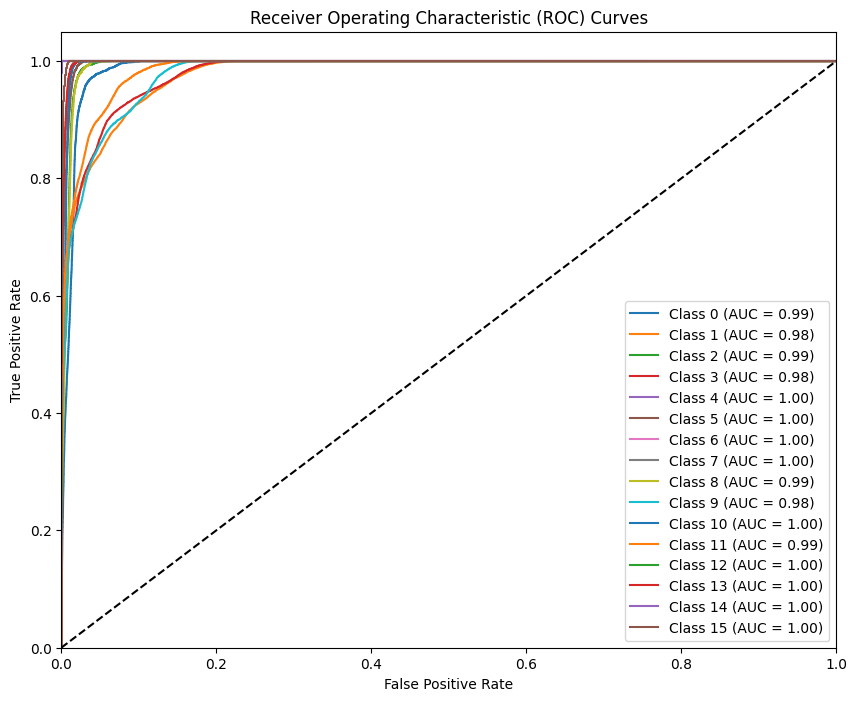

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Initialize the LightGBM Classifier with class weights
lgb_model_with_weight = lgb.LGBMClassifier(random_state=42, class_weight=class_weights)

# Fit the model with class weights using the selected features
lgb_model_with_weight.fit(X_train_selected, y_train)

# Predictions on the training set with class weights
y_train_pred_with_weight_lgb = lgb_model_with_weight.predict(X_train_selected)

# Print classification report for the model with class weights
print("LightGBM Classification Report (With Weights):")
print(classification_report(y_train, y_train_pred_with_weight_lgb))

# Calculate ROC AUC score for each class
y_train_binarized = label_binarize(y_train, classes=sorted(class_weights.keys()))
y_train_prob = lgb_model_with_weight.predict_proba(X_train_selected)

roc_auc_scores = {}
for i, class_label in enumerate(sorted(class_weights.keys())):
    roc_auc = roc_auc_score(y_train_binarized[:, i], y_train_prob[:, i])
    roc_auc_scores[class_label] = roc_auc

# Print ROC AUC scores for each class
print("\nROC AUC Scores:")
for class_label, roc_auc in roc_auc_scores.items():
    print(f"Class '{class_label}': AUC = {roc_auc:.4f}")

# Plot ROC curves for all classes
plt.figure(figsize=(10, 8))

for i, class_label in enumerate(sorted(class_weights.keys())):
    fpr, tpr, _ = roc_curve(y_train_binarized[:, i], y_train_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc_scores[class_label]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.show()


In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.8 MB/s eta 0:00:00


CatBoost Classification Report (With Weights):
              precision    recall  f1-score   support

           0       0.64      0.36      0.46      3084
           1       0.93      0.66      0.77     27441
           2       0.63      0.42      0.50      2252
           3       0.86      0.69      0.77     19729
           4       0.67      0.69      0.68       453
           5       0.75      0.76      0.76      3851
           6       0.63      0.73      0.68       314
           7       0.73      0.77      0.75      2701
           8       0.53      0.75      0.62      2308
           9       0.69      0.88      0.78     19816
          10       0.61      0.72      0.66      1558
          11       0.70      0.93      0.79     13717
          12       0.73      0.90      0.81       296
          13       0.64      0.99      0.78      2786
          14       0.84      0.95      0.89       214
          15       0.66      1.00      0.79      1928

    accuracy                     

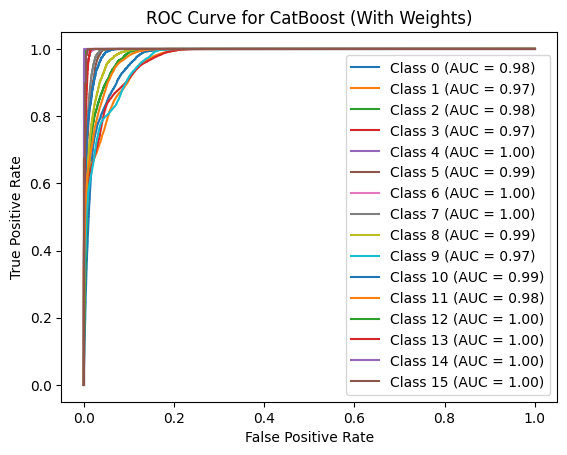

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Define the target variable from the training DataFrame
y_train = train_df_rf['Personality']

# Binarize the labels for multi-class ROC
y_train_binarized = label_binarize(y_train, classes=sorted(class_weights.keys()))
n_classes = y_train_binarized.shape[1]

# ===================== CatBoost with weights =========================
# Initialize the CatBoost Classifier with class weights
catboost_model_with_weight = CatBoostClassifier(random_state=42, class_weights=list(class_weights.values()), verbose=0)

# Fit the model with class weights using the selected features
catboost_model_with_weight.fit(X_train_selected, y_train)

# Predictions on the training set with class weights
y_train_pred_with_weight_catboost = catboost_model_with_weight.predict(X_train_selected)

# Print classification report for the model with class weights
print("CatBoost Classification Report (With Weights):")
print(classification_report(y_train, y_train_pred_with_weight_catboost))

# ROC for CatBoost with weights
y_train_prob_with_weight_catboost = catboost_model_with_weight.predict_proba(X_train_selected)

fpr_with_weight_catboost = {}
tpr_with_weight_catboost = {}
roc_auc_with_weight_catboost = {}

for i in range(n_classes):
    fpr_with_weight_catboost[i], tpr_with_weight_catboost[i], _ = roc_curve(y_train_binarized[:, i], y_train_prob_with_weight_catboost[:, i])
    roc_auc_with_weight_catboost[i] = auc(fpr_with_weight_catboost[i], tpr_with_weight_catboost[i])

# Plot ROC curve for CatBoost with weights
plt.figure()
for i in range(n_classes):
    plt.plot(fpr_with_weight_catboost[i], tpr_with_weight_catboost[i], label=f'Class {i} (AUC = {roc_auc_with_weight_catboost[i]:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for CatBoost (With Weights)')
plt.legend(loc="lower right")
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Classification Report (With Weights):


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.44      0.05      0.09      3084
           1       0.64      0.92      0.75     27441
           2       0.00      0.00      0.00      2252
           3       0.33      0.09      0.15     19729
           4       0.56      0.63      0.60       453
           5       0.60      0.78      0.68      3851
           6       0.31      0.16      0.21       314
           7       0.40      0.17      0.24      2701
           8       1.00      0.00      0.00      2308
           9       0.32      0.06      0.10     19816
          10       0.03      0.92      0.06      1558
          11       0.29      0.01      0.01     13717
          12       0.21      0.29      0.24       296
          13       0.40      0.30      0.34      2786
          14       0.25      0.01      0.02       214
          15       0.58      0.01      0.02      1928

    accuracy                           0.34    102448
   macro avg       0.40   

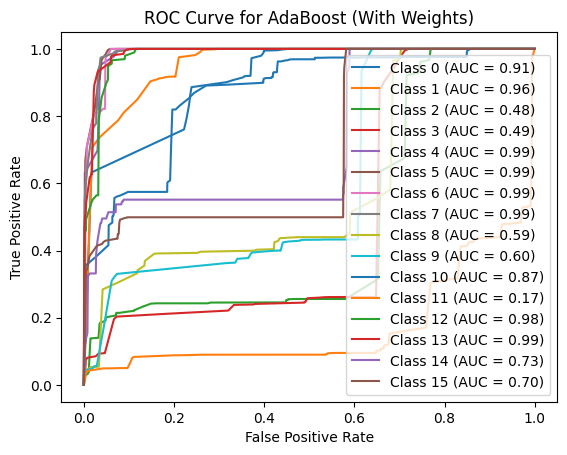

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Binarize the labels for multi-class ROC
y_train_binarized = label_binarize(y_train, classes=sorted(class_weights.keys()))
n_classes = y_train_binarized.shape[1]

# ===================== AdaBoost with weights =========================
# Initialize the AdaBoost Classifier
adaboost_model_with_weight = AdaBoostClassifier(random_state=42)

# Fit the model with sample weights using the selected features and previous weights
adaboost_model_with_weight.fit(X_train_selected, y_train, sample_weight=sample_weights)

# Predictions on the training set with sample weights
y_train_pred_with_weight_adaboost = adaboost_model_with_weight.predict(X_train_selected)

# Print classification report for the model with sample weights
print("AdaBoost Classification Report (With Weights):")
print(classification_report(y_train, y_train_pred_with_weight_adaboost))

# ROC for AdaBoost with weights
y_train_prob_with_weight_adaboost = adaboost_model_with_weight.predict_proba(X_train_selected)

fpr_with_weight_adaboost = {}
tpr_with_weight_adaboost = {}
roc_auc_with_weight_adaboost = {}

for i in range(n_classes):
    fpr_with_weight_adaboost[i], tpr_with_weight_adaboost[i], _ = roc_curve(y_train_binarized[:, i], y_train_prob_with_weight_adaboost[:, i])
    roc_auc_with_weight_adaboost[i] = auc(fpr_with_weight_adaboost[i], tpr_with_weight_adaboost[i])

# Plot ROC curve for AdaBoost with weights
plt.figure()
for i in range(n_classes):
    plt.plot(fpr_with_weight_adaboost[i], tpr_with_weight_adaboost[i], label=f'Class {i} (AUC = {roc_auc_with_weight_adaboost[i]:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for AdaBoost (With Weights)')
plt.legend(loc="lower right")
plt.show()


Gradient Boosting Classification Report (With Weights):
              precision    recall  f1-score   support

           0       0.54      0.69      0.61      3084
           1       0.93      0.74      0.82     27441
           2       0.51      0.75      0.61      2252
           3       0.85      0.78      0.81     19729
           4       0.51      0.88      0.65       453
           5       0.72      0.79      0.75      3851
           6       0.47      0.94      0.62       314
           7       0.64      0.83      0.73      2701
           8       0.50      0.74      0.60      2308
           9       0.83      0.78      0.80     19816
          10       0.48      0.79      0.59      1558
          11       0.78      0.82      0.80     13717
          12       0.40      0.92      0.55       296
          13       0.66      0.83      0.73      2786
          14       0.42      0.95      0.59       214
          15       0.62      0.85      0.71      1928

    accuracy            

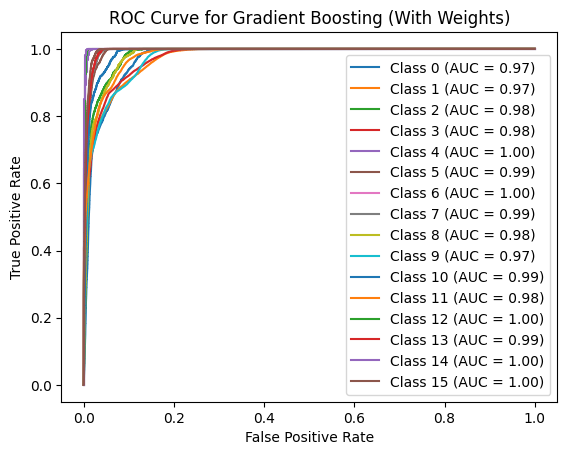

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Binarize the labels for multi-class ROC
y_train_binarized = label_binarize(y_train, classes=sorted(class_weights.keys()))
n_classes = y_train_binarized.shape[1]

# ===================== Gradient Boosting with weights =========================
# Initialize the Gradient Boosting Classifier with class weights
gbm_model_with_weight = GradientBoostingClassifier(random_state=42)

# Fit the model with sample weights using the selected features
gbm_model_with_weight.fit(X_train_selected, y_train, sample_weight=sample_weights)

# Predictions on the training set with sample weights
y_train_pred_with_weight_gbm = gbm_model_with_weight.predict(X_train_selected)

# Print classification report for the model with class weights
print("Gradient Boosting Classification Report (With Weights):")
print(classification_report(y_train, y_train_pred_with_weight_gbm))

# ROC for Gradient Boosting with weights
y_train_prob_with_weight_gbm = gbm_model_with_weight.predict_proba(X_train_selected)

fpr_with_weight_gbm = {}
tpr_with_weight_gbm = {}
roc_auc_with_weight_gbm = {}

for i in range(n_classes):
    fpr_with_weight_gbm[i], tpr_with_weight_gbm[i], _ = roc_curve(y_train_binarized[:, i], y_train_prob_with_weight_gbm[:, i])
    roc_auc_with_weight_gbm[i] = auc(fpr_with_weight_gbm[i], tpr_with_weight_gbm[i])

# Plot ROC curve for Gradient Boosting with weights
plt.figure()
for i in range(n_classes):
    plt.plot(fpr_with_weight_gbm[i], tpr_with_weight_gbm[i], label=f'Class {i} (AUC = {roc_auc_with_weight_gbm[i]:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Gradient Boosting (With Weights)')
plt.legend(loc="lower right")
plt.show()
